In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE

STEP 1: LOAD AND EXPLORE THE DATASET


In [ ]:
data = pd.read_csv('creditcard.csv')
print("  DATA SHAPE ")
print(data.shape)

print("\n  DATA COLUMNS ")
print(data.columns)

print("\n DATA HEAD ")
print(data.head())

print("\n TARGET CLASS DISTRIBUTION (IMBALANCED) ")
print(data['Class'].value_counts())

--------- DATA SHAPE ---------
(284807, 31)

--------- DATA COLUMNS ---------
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

--------- DATA HEAD ---------
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.06

STEP 2: ISOLATE FEATURES AND TARGETS

In [3]:
X = data.drop(columns=['Class'])
y = data['Class']

STEP 3: TRAIN-TEST SPLIT (80% Train, 20% Test)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("\n  SPLIT MATRIX SHAPES ")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")


  SPLIT MATRIX SHAPES 
X_train shape: (227845, 30), X_test shape: (56962, 30)
y_train shape: (227845,), y_test shape: (56962,)


STEP 4: BALANCE DATA USING SMOTE

In [6]:
print("\nApplying SMOTE balancing step...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\n BALANCED TRAINING DISTRIBUTION ")
print(pd.Series(y_train_balanced).value_counts())


Applying SMOTE balancing step...

 BALANCED TRAINING DISTRIBUTION 
Class
0    227451
1    227451
Name: count, dtype: int64


STEP 5: MODEL CONFIGURATION AND LOGIC FITTING

In [7]:
print("\nTraining the model layout...")
classifier = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)
classifier.fit(X_train_balanced, y_train_balanced)
print("Model training complete!")


Training the model layout...
Model training complete!


STEP 6: TESTING & PERFORMANCE SCORE CALCULATIONS

In [8]:
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1] # Probability arrays needed for AUC math

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)
score_roc = roc_auc_score(y_test, y_proba)
score_pr = average_precision_score(y_test, y_proba)

print("\n--------- PERFORMANCE SCORES --------")
print("Accuracy Score is {}%".format(round(score1 * 100, 3)))
print("Precision Score is {}%".format(round(score2 * 100, 3)))
print("Recall Score is {}%".format(round(score3 * 100, 3)))
print("AUC-ROC Score is {}%".format(round(score_roc * 100, 3)))
print("AUC-PR Score is {}%".format(round(score_pr * 100, 3)))


--------- PERFORMANCE SCORES --------
Accuracy Score is 99.939%
Precision Score is 83.158%
Recall Score is 80.612%
AUC-ROC Score is 95.781%
AUC-PR Score is 82.592%


 STEP 7: VISUALIZING PERFORMANCE GRAPH (CONFUSION MATRIX)

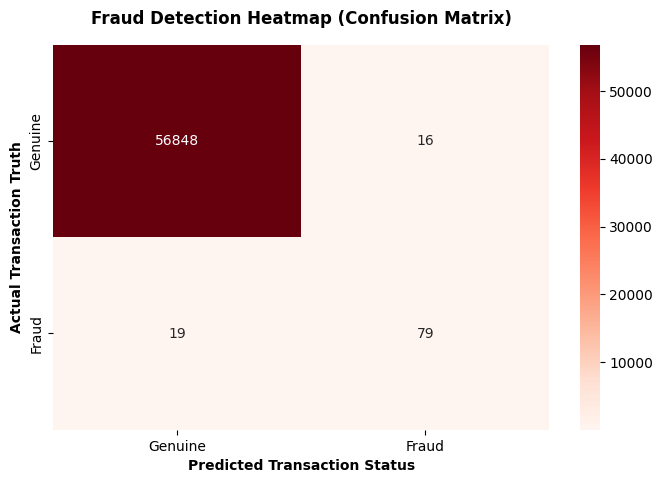

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Reds", 
            xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
plt.xlabel('Predicted Transaction Status', fontweight='bold')
plt.ylabel('Actual Transaction Truth', fontweight='bold')
plt.title('Fraud Detection Heatmap (Confusion Matrix)', fontsize=12, fontweight='bold', pad=15)
plt.show()

STEP 8: ANALYZING REAL REVIEWS (CUSTOM DATA SIMULATION)

In [13]:
def predict_custom_transaction(feature_list):
    array_input = np.array(feature_list).reshape(1, -1)
    df_input = pd.DataFrame(array_input, columns=X.columns)
    return classifier.predict(df_input)

print("\n" + "="*70)
print("             BATCH TESTING REAL TRANSACTION SAMPLES            ")
print("="*70)

genuine_samples = X_test[y_test == 0].head(2)
fraud_samples = X_test[y_test == 1].head(1)

sample_batch = pd.concat([genuine_samples, fraud_samples])
actual_labels = [0, 0, 1]

for idx, (index_id, row) in enumerate(sample_batch.iterrows()):
    feature_list = list(row)
    prediction = predict_custom_transaction(feature_list)
    
    true_status = "FRAUD 🚨" if actual_labels[idx] == 1 else "GENUINE ✅"
    pred_status = "FRAUD 🚨" if prediction == 1 else "GENUINE ✅"
    
    print(f"Sample #{idx + 1} (Row Index: {index_id})")
    print(f"  ↳ Time Elapsed : {int(row['Time'])} seconds")
    print(f"  ↳ Amount Spent : ${row['Amount']:.2f}")
    print(f"  ↳ True Status  : {true_status}")
    print(f"  ↳ ML Prediction: {pred_status}")
    
    if actual_labels[idx] == prediction:
        print("  Verdict        : CORRECT MATCH ⭐")
    else:
        print("  Verdict        : MISCLASSIFIED ❌")
    print("-" * 70)


             BATCH TESTING REAL TRANSACTION SAMPLES            
Sample #1 (Row Index: 263020)
  ↳ Time Elapsed : 160760 seconds
  ↳ Amount Spent : $23.00
  ↳ True Status  : GENUINE ✅
  ↳ ML Prediction: GENUINE ✅
  Verdict        : CORRECT MATCH ⭐
----------------------------------------------------------------------
Sample #2 (Row Index: 11378)
  ↳ Time Elapsed : 19847 seconds
  ↳ Amount Spent : $11.85
  ↳ True Status  : GENUINE ✅
  ↳ ML Prediction: GENUINE ✅
  Verdict        : CORRECT MATCH ⭐
----------------------------------------------------------------------
Sample #3 (Row Index: 77348)
  ↳ Time Elapsed : 57007 seconds
  ↳ Amount Spent : $0.01
  ↳ True Status  : FRAUD 🚨
  ↳ ML Prediction: FRAUD 🚨
  Verdict        : CORRECT MATCH ⭐
----------------------------------------------------------------------
